In [ ]:
# ============================================================
# MERITI INC — ML ASSESSMENT
# Step 1: Environment Setup & Verification
# ============================================================

# ── 1.1  IMPORTS & VERSION CHECK ────────────────────────────
import subprocess
import sys
import os

def install(package: str) -> None:
    """Install a package via pip quietly."""
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", package, "-q"],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL
    )

print("Installing dependencies...")
install("segmentation-models-pytorch")
install("albumentations")
install("gdown")

# ── 1.2  CORE IMPORTS ───────────────────────────────────────
import torch
import torchvision
import segmentation_models_pytorch as smp
import albumentations
import gdown
import numpy as np
from pathlib import Path

print("\n── Library versions ──────────────────────────────────")
print(f"  torch:                       {torch.__version__}")
print(f"  torchvision:                 {torchvision.__version__}")
print(f"  segmentation_models_pytorch: {smp.__version__}")
print(f"  albumentations:              {albumentations.__version__}")
print(f"  numpy:                       {np.__version__}")

# ── 1.3  GPU CHECK ──────────────────────────────────────────
print("\n── GPU check ─────────────────────────────────────────")
if not torch.cuda.is_available():
    raise RuntimeError(
        "No GPU detected!\n"
        "Go to Runtime > Change runtime type > Hardware accelerator > T4 GPU\n"
        "Then re-run this cell."
    )

gpu_name = torch.cuda.get_device_name(0)
gpu_mem  = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
print(f"  GPU:    {gpu_name}")
print(f"  VRAM:   {gpu_mem:.1f} GB")
print(f"  CUDA:   {torch.version.cuda}")

# ── 1.4  GOOGLE DRIVE MOUNT ─────────────────────────────────
print("\n── Mounting Google Drive ─────────────────────────────")
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    print("  Drive mounted at /content/drive")
except ModuleNotFoundError:
    # Running outside Colab (local dev/testing)
    print("  Not in Colab — skipping Drive mount (local mode)")

# ── 1.5  PROJECT FOLDER STRUCTURE ───────────────────────────
print("\n── Creating project folder structure ─────────────────")

BASE_DIR = Path("/content/drive/MyDrive/meriti_project")

DIRS = {
    "data":        BASE_DIR / "data",
    "checkpoints": BASE_DIR / "checkpoints",
    "outputs":     BASE_DIR / "outputs",
    "logs":        BASE_DIR / "logs",
}

for name, path in DIRS.items():
    path.mkdir(parents=True, exist_ok=True)
    print(f"  ✓ {name:15s} → {path}")

# ── 1.6  GLOBAL CONFIG DICT ─────────────────────────────────
# Single source of truth for all paths and hyperparameters.
# Every subsequent step imports from here — no hardcoded values anywhere.

CONFIG = {
    # ── Paths ──────────────────────────────────────────────
    "base_dir":         str(BASE_DIR),
    "data_dir":         str(DIRS["data"]),
    "checkpoint_dir":   str(DIRS["checkpoints"]),
    "output_dir":       str(DIRS["outputs"]),
    "log_dir":          str(DIRS["logs"]),
    "log_csv":          str(DIRS["logs"] / "training_log.csv"),
    "best_ckpt":        str(DIRS["checkpoints"] / "best_model.pth"),
    "train_img_dir":    str(DIRS["data"] / "train" / "images_png"),
    "train_mask_dir":   str(DIRS["data"] / "train" / "masks_png"),
    "val_img_dir":      str(DIRS["data"] / "val" / "images_png"),   # Added for validation data
    "val_mask_dir":     str(DIRS["data"] / "val" / "masks_png"),   # Added for validation data

    # ── Dataset ────────────────────────────────────────────
    "dataset":          "LoveDA",
    "num_classes":      7,
    "class_names":      [
                            "background",
                            "building",
                            "road",
                            "water",
                            "barren",
                            "forest",
                            "agriculture",
                        ],
    "image_size":       512,       # resize from 1024×1024
    "ignore_index":     -1,        # unlabeled pixels in point mask

    # ── Point label sampling ───────────────────────────────
    "n_points_per_class": 5,       # Experiment 1 variable (1,3,5,10,20)
    "sampling_seed":    42,

    # ── Model ──────────────────────────────────────────────
    "architecture":     "UNet",
    "encoder":          "resnet34",
    "encoder_weights":  "imagenet",
    "in_channels":      3,

    # ── Loss ───────────────────────────────────────────────
    "focal_gamma":      2.0,       # Experiment 2 variable (0,0.5,1,2,5)
    "loss_eps":         1e-6,

    # ── Training ───────────────────────────────────────────
    "batch_size":       4,
    "num_workers":      2,
    "n_epochs":         50,
    "learning_rate":    1e-4,
    "weight_decay":     1e-4,
    "lr_scheduler":     "cosine",

    # ── Device ─────────────────────────────────────────────
    "device":           "cuda" if torch.cuda.is_available() else "cpu",
}

print("\n── CONFIG loaded ─────────────────────────────────────")
for k, v in CONFIG.items():
    if k != "class_names":
        print(f"  {k:25s}: {v}")
print(f"  {'class_names':25s}: {CONFIG['class_names']}")

# ── 1.7  REPRODUCIBILITY SEED ───────────────────────────────
def set_seed(seed: int = 42) -> None:
    """
    Set random seeds across all libraries for full reproducibility.

    Args:
        seed: Integer seed value. Default 42.
    """
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(CONFIG["sampling_seed"])
print(f"\n  Seed set to {CONFIG['sampling_seed']} for full reproducibility")

# ── 1.8  QUICK SMOKE TEST ───────────────────────────────────
print("\n── Smoke test ────────────────────────────────────────")
_x = torch.randn(1, 3, 64, 64).to(CONFIG["device"])
_m = smp.Unet(
    encoder_name    = CONFIG["encoder"],
    encoder_weights = None,           # no download in smoke test
    in_channels     = CONFIG["in_channels"],
    classes         = CONFIG["num_classes"],
).to(CONFIG["device"])

with torch.no_grad():
    _out = _m(_x)

assert _out.shape == (1, CONFIG["num_classes"], 64, 64), \
    f"Unexpected output shape: {_out.shape}"

print(f"  UNet forward pass OK — output shape: {tuple(_out.shape)}")

del _x, _m, _out
torch.cuda.empty_cache()

print("\n✓ Step 1 complete — environment ready, CONFIG loaded, GPU verified")
print(f"  Working on: {CONFIG['device'].upper()}  |  Project root: {CONFIG['base_dir']}")

Installing dependencies...

── Library versions ──────────────────────────────────
  torch:                       2.10.0+cu128
  torchvision:                 0.25.0+cu128
  segmentation_models_pytorch: 0.5.0
  albumentations:              2.0.8
  numpy:                       2.0.2

── GPU check ─────────────────────────────────────────
  GPU:    Tesla T4
  VRAM:   14.6 GB
  CUDA:   12.8

── Mounting Google Drive ─────────────────────────────
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Drive mounted at /content/drive

── Creating project folder structure ─────────────────
  ✓ data            → /content/drive/MyDrive/meriti_project/data
  ✓ checkpoints     → /content/drive/MyDrive/meriti_project/checkpoints
  ✓ outputs         → /content/drive/MyDrive/meriti_project/outputs
  ✓ logs            → /content/drive/MyDrive/meriti_project/logs

── CONFIG loaded ─────────────────────────────────────
  base_di

In [ ]:
# ============================================================
# MERITI INC — ML ASSESSMENT
# Step 2: Download & Extract LoveDA Dataset
# ============================================================

print("\n── Downloading LoveDA dataset (urban subset) ─────────")

# Define raw data directory within the main data directory
raw_dir = Path(CONFIG["data_dir"]) / "raw"
raw_dir.mkdir(parents=True, exist_ok=True)

# Official LoveDA URLs from Zenodo (open access, no auth needed)
# These files contain the training and validation images and masks for the urban subset.
URLS = {
    "Train.zip": "https://zenodo.org/record/5706578/files/Train.zip",
    "Val.zip":   "https://zenodo.org/record/5706578/files/Val.zip",
}

# Download the files using wget
for filename, url in URLS.items():
    dest = raw_dir / filename
    if dest.exists() and dest.stat().st_size > 0: # Check if file exists and is non-empty
        print(f"  ✓ {filename} already exists and is non-empty — skipping download.")
        continue
    print(f"  Downloading {filename} from Zenodo...")
    # Use !wget to execute the command in the shell
    !wget -q --show-progress -O "{dest}" "{url}"

    # Verify if the download was successful and not 0 bytes
    if not (dest.exists() and dest.stat().st_size > 0):
        if dest.exists():
            dest.unlink() # Delete incomplete/empty file
        raise FileNotFoundError(
            f"Failed to download {filename} from Zenodo. "
            "Please check the URL or your network connection."
        )
    print(f"  ✓ {filename} done.")


# Extract the dataset
print("\n── Extracting dataset ────────────────────────────")
import zipfile
import shutil # Import shutil for rmtree

# Define the path to the downloaded Train.zip and Val.zip
train_zip_path = raw_dir / "Train.zip"
val_zip_path = raw_dir / "Val.zip"

# Expected final directory for training data (lowercase 'train')
expected_train_final_dir = Path(CONFIG["data_dir"]) / "train"
train_img_subdir = expected_train_final_dir / "images_png"
train_mask_subdir = expected_train_final_dir / "masks_png"

# Extract Train.zip
# Check if the final directory doesn't exist OR if critical subdirectories are missing
if not expected_train_final_dir.exists() or not (train_img_subdir.exists() and train_mask_subdir.exists()):
    if not train_zip_path.exists() or train_zip_path.stat().st_size == 0:
        raise FileNotFoundError(f"'{train_zip_path.name}' not found or is empty. Cannot extract.")

    print(f"  Extracting {train_zip_path.name} to {CONFIG['data_dir']}...")

    # Create the target directory for the normalized structure
    expected_train_final_dir.mkdir(parents=True, exist_ok=True)

    # Extract to a temporary location to inspect contents
    temp_extract_dir = Path(CONFIG["data_dir"]) / "temp_train_extract"
    if temp_extract_dir.exists():
        shutil.rmtree(temp_extract_dir)
    temp_extract_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(train_zip_path, 'r') as zip_ref:
        zip_ref.extractall(temp_extract_dir)

    # Now, find 'images_png' and 'masks_png' within the temporary directory
    found_train_img = None
    found_train_mask = None

    for root, dirs, files in os.walk(temp_extract_dir):
        if "images_png" in dirs:
            found_train_img = Path(root) / "images_png"
        if "masks_png" in dirs:
            found_train_mask = Path(root) / "masks_png"
        if found_train_img and found_train_mask: # Found both, break early
            break

    if not found_train_img or not found_train_mask:
        shutil.rmtree(temp_extract_dir)
        raise FileNotFoundError(f"Could not find 'images_png' or 'masks_png' within extracted '{train_zip_path.name}'. "
                                f"Extracted contents to: {temp_extract_dir}. Please check its structure.")

    # If the final subdirectories already exist but are malformed, remove them before moving
    if train_img_subdir.exists():
        shutil.rmtree(train_img_subdir)
    if train_mask_subdir.exists():
        shutil.rmtree(train_mask_subdir)

    # Move them to the final expected location
    shutil.move(str(found_train_img), str(train_img_subdir))
    shutil.move(str(found_train_mask), str(train_mask_subdir))

    # Clean up temporary directory and any other top-level folders created by the zip
    shutil.rmtree(temp_extract_dir)

    print("  Extraction of training data complete.")
else:
    print(f"  ✓ Training data already extracted and verified in {expected_train_final_dir}.")


# Expected final directory for validation data (lowercase 'val')
expected_val_final_dir = Path(CONFIG["data_dir"]) / "val"
val_img_subdir = expected_val_final_dir / "images_png"
val_mask_subdir = expected_val_final_dir / "masks_png"

# Extract Val.zip
# Check if the final directory doesn't exist OR if critical subdirectories are missing
if not expected_val_final_dir.exists() or not (val_img_subdir.exists() and val_mask_subdir.exists()):
    if not val_zip_path.exists() or val_zip_path.stat().st_size == 0:
        raise FileNotFoundError(f"'{val_zip_path.name}' not found or is empty. Cannot extract.")

    print(f"  Extracting {val_zip_path.name} to {CONFIG['data_dir']}...")

    # Create the target directory for the normalized structure
    expected_val_final_dir.mkdir(parents=True, exist_ok=True)

    # Extract to a temporary location to inspect contents
    temp_extract_dir = Path(CONFIG["data_dir"]) / "temp_val_extract"
    if temp_extract_dir.exists():
        shutil.rmtree(temp_extract_dir)
    temp_extract_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(val_zip_path, 'r') as zip_ref:
        zip_ref.extractall(temp_extract_dir)

    # Now, find 'images_png' and 'masks_png' within the temporary directory
    found_val_img = None
    found_val_mask = None

    for root, dirs, files in os.walk(temp_extract_dir):
        if "images_png" in dirs:
            found_val_img = Path(root) / "images_png"
        if "masks_png" in dirs:
            found_val_mask = Path(root) / "masks_png"
        if found_val_img and found_val_mask: # Found both, break early
            break

    if not found_val_img or not found_val_mask:
        shutil.rmtree(temp_extract_dir)
        raise FileNotFoundError(f"Could not find 'images_png' or 'masks_png' within extracted '{val_zip_path.name}'. "
                                f"Extracted contents to: {temp_extract_dir}. Please check its structure.")

    # If the final subdirectories already exist but are malformed, remove them before moving
    if val_img_subdir.exists():
        shutil.rmtree(val_img_subdir)
    if val_mask_subdir.exists():
        shutil.rmtree(val_mask_subdir)

    # Move them to the final expected location
    shutil.move(str(found_val_img), str(val_img_subdir))
    shutil.move(str(found_val_mask), str(val_mask_subdir))

    # Clean up temporary directory and any other top-level folders created by the zip
    shutil.rmtree(temp_extract_dir)

    print("  Extraction of validation data complete.")
else:
    print(f"  ✓ Validation data already extracted and verified in {expected_val_final_dir}.")

print("\n✓ Step 2 complete — dataset downloaded and extracted.")

# ── 2.2  VERIFY DIRECTORY STRUCTURE ─────────────────────────
print("\n── Verifying dataset directory structure ─────────────")

# Check for existence of expected image and mask directories for training
train_img_dir = Path(CONFIG["data_dir"]) / "train" / "images_png"
train_mask_dir = Path(CONFIG["data_dir"]) / "train" / "masks_png"

if not train_img_dir.exists() or not train_img_dir.is_dir():
    raise FileNotFoundError(f"Training image directory not found: {train_img_dir}")
if not train_mask_dir.exists() or not train_mask_dir.is_dir():
    raise FileNotFoundError(f"Training mask directory not found: {train_mask_dir}")

print(f"  ✓ Training image directory: {train_img_dir}")
print(f"  ✓ Training mask directory: {train_mask_dir}")

# Check for existence of expected image and mask directories for validation
val_img_dir = Path(CONFIG["data_dir"]) / "val" / "images_png"
val_mask_dir = Path(CONFIG["data_dir"]) / "val" / "masks_png"

if not val_img_dir.exists() or not val_img_dir.is_dir():
    raise FileNotFoundError(f"Validation image directory not found: {val_img_dir}")
if not val_mask_dir.exists() or not val_mask_dir.is_dir():
    raise FileNotFoundError(f"Validation mask directory not found: {val_mask_dir}")

print(f"  ✓ Validation image directory: {val_img_dir}")
print(f"  ✓ Validation mask directory: {val_mask_dir}")

# Further checks: count files, ensure non-empty, etc.
num_train_images = len(list(train_img_dir.glob("*.png")))
num_train_masks = len(list(train_mask_dir.glob("*.png")))
num_val_images = len(list(val_img_dir.glob("*.png")))
num_val_masks = len(list(val_mask_dir.glob("*.png")))

print(f"  Found {num_train_images} training images and {num_train_masks} training masks.")
print(f"  Found {num_val_images} validation images and {num_val_masks} validation masks.")

if num_train_images == 0 or num_train_masks == 0 or num_val_images == 0 or num_val_masks == 0:
    print("  WARNING: Some dataset directories appear empty. Please check the download and extraction process.")
else:
    print("  ✓ Dataset directory structure and content counts look good.")



── Downloading LoveDA dataset (urban subset) ─────────
  ✓ Train.zip already exists and is non-empty — skipping download.
  ✓ Val.zip already exists and is non-empty — skipping download.

── Extracting dataset ────────────────────────────
  Extracting Train.zip to /content/drive/MyDrive/meriti_project/data...
  Extraction of training data complete.
  Extracting Val.zip to /content/drive/MyDrive/meriti_project/data...
  Extraction of validation data complete.

✓ Step 2 complete — dataset downloaded and extracted.

── Verifying dataset directory structure ─────────────
  ✓ Training image directory: /content/drive/MyDrive/meriti_project/data/train/images_png
  ✓ Training mask directory: /content/drive/MyDrive/meriti_project/data/train/masks_png
  ✓ Validation image directory: /content/drive/MyDrive/meriti_project/data/val/images_png
  ✓ Validation mask directory: /content/drive/MyDrive/meriti_project/data/val/masks_png
  Found 1366 training images and 1366 training masks.
  Found 992 val

── Building datasets ─────────────────────────────────
  Train dataset: 1366 images
  Val dataset:    992 images
  Train batches: 341
  Val batches:   248

── Running Dataset unit tests ────────────────────────
  ✓ Test 1 passed — output tensor shapes are correct
  ✓ Test 2 passed — tensor dtypes are correct
  ✓ Test 3 passed — point_mask is binary
  ✓ Test 4 passed — label values are valid
  ✓ Test 5 passed — val dataset has no point supervision
  ✓ Test 6 passed — DataLoader batches are correct shape

  All 6 unit tests passed ✓

── Visualising one training batch ────────────────────


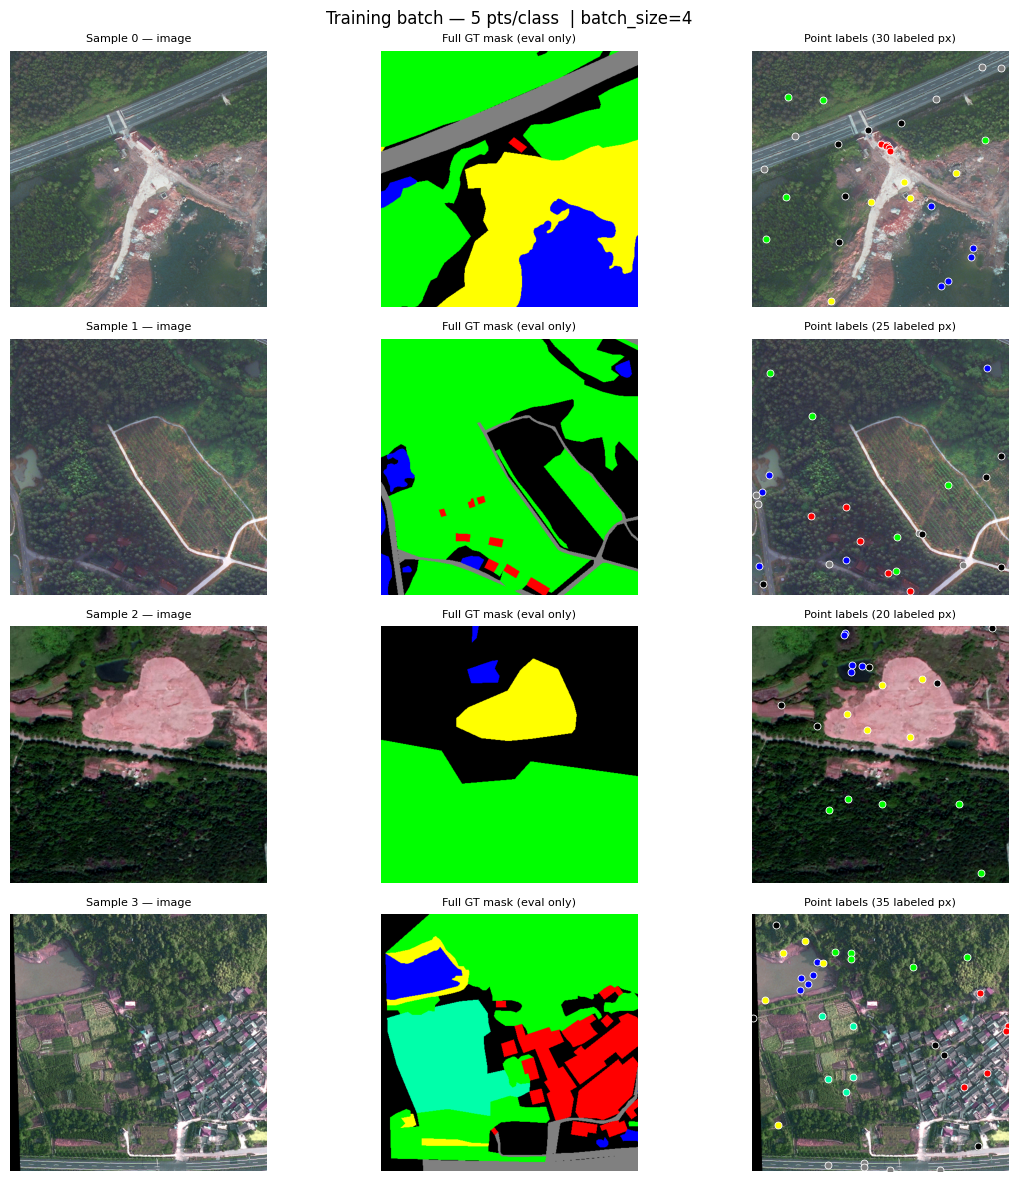

  Batch visualisation saved to /content/drive/MyDrive/meriti_project/outputs/training_batch_vis.png

✓ Step 4 complete — Dataset and DataLoader ready
  341 train batches | 248 val batches


In [ ]:
# ============================================================
# MERITI INC — ML ASSESSMENT
# Step 4: PyTorch Dataset Class & DataLoader
# ============================================================
# Paste this cell AFTER Step 3. CONFIG and PointLabelSampler
# must already be defined.
# ============================================================

import torch
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from PIL import Image
from typing import Dict, Tuple, Optional
import matplotlib.pyplot as plt


# ── 4.1  AUGMENTATION PIPELINES ─────────────────────────────

def get_train_transforms(image_size: int) -> A.Compose:
    """
    Training augmentation pipeline.

    Applies spatial and colour augmentations. Masks receive identical
    spatial transforms but no colour jitter (they are label maps).

    Args:
        image_size: Target H and W after resize.

    Returns:
        Albumentations Compose pipeline.
    """
    return A.Compose([
        A.Resize(image_size, image_size, interpolation=1),  # BILINEAR
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.2,
            hue=0.1,
            p=0.5,
        ),
        A.Normalize(
            mean=(0.485, 0.456, 0.406),   # ImageNet stats
            std=(0.229, 0.224, 0.225),
        ),
        ToTensorV2(),
    ])


def get_val_transforms(image_size: int) -> A.Compose:
    """
    Validation augmentation pipeline — resize and normalise only.

    Args:
        image_size: Target H and W after resize.

    Returns:
        Albumentations Compose pipeline.
    """
    return A.Compose([
        A.Resize(image_size, image_size, interpolation=1),
        A.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225),
        ),
        ToTensorV2(),
    ])


# ── 4.2  DATASET CLASS ──────────────────────────────────────

class LoveDAPointDataset(Dataset):
    """
    PyTorch Dataset for LoveDA Urban with sparse point label supervision.

    Each sample returns:
        image        — normalised RGB tensor (3, H, W)
        point_mask   — binary tensor (H, W), 1 at labeled pixels
        point_labels — sparse label tensor (H, W), -1 at unlabeled pixels
        full_gt_mask — complete GT mask (H, W), used ONLY for evaluation

    The full_gt_mask is intentionally kept separate from the training signal
    to reflect the real weakly-supervised scenario — the model never sees
    complete masks during training, only sparse point labels.

    Args:
        img_dir:            Directory containing RGB .png images.
        mask_dir:           Directory containing GT mask .png files.
        transforms:         Albumentations transform pipeline.
        sampler:            PointLabelSampler instance.
        is_train:           If True applies point sampling; val returns
                            full masks for evaluation.
        num_classes:        Number of semantic classes.
    """

    def __init__(
        self,
        img_dir:     Path,
        mask_dir:    Path,
        transforms:  A.Compose,
        sampler:     PointLabelSampler,
        is_train:    bool = True,
        num_classes: int  = 7,
    ) -> None:
        self.img_dir     = Path(img_dir)
        self.mask_dir    = Path(mask_dir)
        self.transforms  = transforms
        self.sampler     = sampler
        self.is_train    = is_train
        self.num_classes = num_classes

        self.img_paths = sorted(self.img_dir.glob("*.png"))

        if len(self.img_paths) == 0:
            raise FileNotFoundError(
                f"No .png images found in {self.img_dir}\n"
                f"Check CONFIG['train_img_dir'] / CONFIG['val_img_dir']"
            )

    def __len__(self) -> int:
        return len(self.img_paths)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        """
        Load and return one sample.

        Args:
            idx: Sample index.

        Returns:
            Dict with keys: image, point_mask, point_labels, full_gt_mask.
        """
        img_path  = self.img_paths[idx]
        mask_path = self.mask_dir / img_path.name

        # Load image (RGB) and mask
        image   = np.array(Image.open(img_path).convert("RGB"), dtype=np.uint8)
        mask_np = np.array(Image.open(mask_path),               dtype=np.int64)

        # LoveDA uses 1-indexed classes — remap to 0-indexed [0, num_classes-1]
        mask_np = np.clip(mask_np - 1, 0, self.num_classes - 1)

        # Apply spatial + colour augmentations
        augmented = self.transforms(image=image, mask=mask_np)
        image_t   = augmented["image"]           # (3, H, W) float32
        mask_t    = augmented["mask"].long()     # (H, W)    int64

        # Generate sparse point labels (train only)
        if self.is_train:
            point_mask, point_labels = self.sampler(mask_t, image_idx=idx)
        else:
            # Validation: return empty point supervision
            # Evaluation uses full_gt_mask instead
            H, W         = mask_t.shape
            point_mask   = torch.zeros((H, W), dtype=torch.uint8)
            point_labels = torch.full((H, W), -1, dtype=torch.long)

        return {
            "image":        image_t,        # (3, H, W) — model input
            "point_mask":   point_mask,     # (H, W)    — loss mask
            "point_labels": point_labels,   # (H, W)    — sparse GT
            "full_gt_mask": mask_t,         # (H, W)    — eval only
        }


# ── 4.3  BUILD DATASETS & DATALOADERS ───────────────────────

print("── Building datasets ─────────────────────────────────")

_sampler = PointLabelSampler(
    n_points_per_class = CONFIG["n_points_per_class"],
    seed               = CONFIG["sampling_seed"],
)

train_dataset = LoveDAPointDataset(
    img_dir     = Path(CONFIG["train_img_dir"]),
    mask_dir    = Path(CONFIG["train_mask_dir"]),
    transforms  = get_train_transforms(CONFIG["image_size"]),
    sampler     = _sampler,
    is_train    = True,
    num_classes = CONFIG["num_classes"],
)

val_dataset = LoveDAPointDataset(
    img_dir     = Path(CONFIG["val_img_dir"]),
    mask_dir    = Path(CONFIG["val_mask_dir"]),
    transforms  = get_val_transforms(CONFIG["image_size"]),
    sampler     = _sampler,
    is_train    = False,
    num_classes = CONFIG["num_classes"],
)

print(f"  Train dataset: {len(train_dataset):4d} images")
print(f"  Val dataset:   {len(val_dataset):4d} images")

train_loader = DataLoader(
    train_dataset,
    batch_size  = CONFIG["batch_size"],
    shuffle     = True,
    num_workers = CONFIG["num_workers"],
    pin_memory  = True,
    drop_last   = True,      # keeps batch size consistent
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = CONFIG["batch_size"],
    shuffle     = False,
    num_workers = CONFIG["num_workers"],
    pin_memory  = True,
)

print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")


# ── 4.4  UNIT TESTS ─────────────────────────────────────────
print("\n── Running Dataset unit tests ────────────────────────")

# Test 1: output shapes are correct
sample = train_dataset[0]
H = W = CONFIG["image_size"]
C = CONFIG["num_classes"]

assert sample["image"].shape        == (3, H, W), \
    f"Image shape wrong: {sample['image'].shape}"
assert sample["point_mask"].shape   == (H, W), \
    f"point_mask shape wrong: {sample['point_mask'].shape}"
assert sample["point_labels"].shape == (H, W), \
    f"point_labels shape wrong: {sample['point_labels'].shape}"
assert sample["full_gt_mask"].shape == (H, W), \
    f"full_gt_mask shape wrong: {sample['full_gt_mask'].shape}"
print("  ✓ Test 1 passed — output tensor shapes are correct")

# Test 2: image is float, masks are long/uint8
assert sample["image"].dtype        == torch.float32, "Image must be float32"
assert sample["point_labels"].dtype == torch.long,    "point_labels must be int64"
assert sample["full_gt_mask"].dtype == torch.long,    "full_gt_mask must be int64"
print("  ✓ Test 2 passed — tensor dtypes are correct")

# Test 3: point_mask is strictly binary
unique_pm = sample["point_mask"].unique().tolist()
assert all(v in [0, 1] for v in unique_pm), \
    f"point_mask must be binary, got values: {unique_pm}"
print("  ✓ Test 3 passed — point_mask is binary")

# Test 4: labeled pixels have valid class indices, unlabeled have -1
labeled_labels   = sample["point_labels"][sample["point_mask"] == 1]
unlabeled_labels = sample["point_labels"][sample["point_mask"] == 0]
assert (labeled_labels >= 0).all() and (labeled_labels < C).all(), \
    "Labeled pixels must have valid class indices [0, num_classes)"
assert (unlabeled_labels == -1).all(), \
    "Unlabeled pixels must be -1"
print("  ✓ Test 4 passed — label values are valid")

# Test 5: val dataset returns empty point supervision
val_sample = val_dataset[0]
assert val_sample["point_mask"].sum().item() == 0, \
    "Val point_mask should be all zeros (eval uses full_gt_mask)"
print("  ✓ Test 5 passed — val dataset has no point supervision")

# Test 6: DataLoader batches stack correctly
batch = next(iter(train_loader))
B = CONFIG["batch_size"]
assert batch["image"].shape        == (B, 3, H, W)
assert batch["point_mask"].shape   == (B, H, W)
assert batch["point_labels"].shape == (B, H, W)
print("  ✓ Test 6 passed — DataLoader batches are correct shape")

print("\n  All 6 unit tests passed ✓")


# ── 4.5  VISUALISE A TRAINING BATCH ─────────────────────────
print("\n── Visualising one training batch ────────────────────")

CLASS_COLORS = [
    "#000000", "#FF0000", "#808080",
    "#0000FF", "#FFFF00", "#00FF00", "#00FFAA",
]
color_map = np.array(
    [[int(c[1:3], 16), int(c[3:5], 16), int(c[5:7], 16)]
     for c in CLASS_COLORS], dtype=np.uint8
)

# Denormalise image for display
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

def denorm(t: torch.Tensor) -> np.ndarray:
    """Convert normalised tensor (3,H,W) back to uint8 (H,W,3)."""
    img = t.permute(1, 2, 0).cpu().numpy()
    img = (img * STD + MEAN).clip(0, 1)
    return (img * 255).astype(np.uint8)

fig, axes = plt.subplots(B, 3, figsize=(12, B * 3))
fig.suptitle(
    f"Training batch — {CONFIG['n_points_per_class']} pts/class  "
    f"| batch_size={B}",
    fontsize=12
)

for i in range(B):
    img_disp  = denorm(batch["image"][i])
    mask_disp = color_map[batch["full_gt_mask"][i].numpy()]
    pm_np     = batch["point_mask"][i].numpy()
    pl_np     = batch["point_labels"][i].numpy()

    # Image
    axes[i, 0].imshow(img_disp)
    axes[i, 0].set_title(f"Sample {i} — image", fontsize=8)
    axes[i, 0].axis("off")

    # GT mask
    axes[i, 1].imshow(mask_disp)
    axes[i, 1].set_title("Full GT mask (eval only)", fontsize=8)
    axes[i, 1].axis("off")

    # Image + sampled points
    axes[i, 2].imshow(img_disp)
    ys, xs = np.where(pm_np == 1)
    for y, x in zip(ys, xs):
        cls   = int(pl_np[y, x])
        color = CLASS_COLORS[cls] if cls >= 0 else "#FFFFFF"
        axes[i, 2].plot(x, y, "o", color=color,
                        markersize=5, markeredgecolor="white",
                        markeredgewidth=0.6)
    axes[i, 2].set_title(
        f"Point labels ({pm_np.sum()} labeled px)", fontsize=8
    )
    axes[i, 2].axis("off")

plt.tight_layout()
batch_vis_path = Path(CONFIG["output_dir"]) / "training_batch_vis.png"
plt.savefig(str(batch_vis_path), dpi=110, bbox_inches="tight")
plt.show()
print(f"  Batch visualisation saved to {batch_vis_path}")

print("\n✓ Step 4 complete — Dataset and DataLoader ready")
print(f"  {len(train_loader)} train batches | {len(val_loader)} val batches")

In [ ]:
# ============================================================
# MERITI INC — ML ASSESSMENT
# Step 5: Partial Cross-Entropy Loss with Focal Weighting
# ============================================================
# This is the core technical contribution of the assessment.
# Formula from the paper:
#   pCE = Σ( FocalLoss(pred, GT) × MASK_labeled ) / Σ(MASK_labeled)
#
# Paste this cell AFTER Step 4.
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Optional
import os


class PartialFocalLoss(nn.Module):
    """
    Partial Cross-Entropy Loss with Focal weighting for sparse point supervision.

    Standard cross-entropy computes loss over every pixel in an image.
    When only sparse point labels are available, computing loss on unlabeled
    pixels introduces noise and degrades training. This loss restricts
    gradient updates to ONLY the labeled point locations.

    The focal weighting component (Lin et al. 2017) further down-weights
    easy examples and focuses learning on hard, misclassified pixels —
    particularly useful when labeled points may span imbalanced classes.

    Formula:
        FL(p_t)  = -(1 - p_t)^gamma * log(p_t)          [focal loss]
        pCE      = Σ(FL(pred, gt) * mask) / Σ(mask)     [partial aggregation]

    where:
        p_t    = softmax probability assigned to the correct class
        gamma  = focusing parameter (0 = standard CE, 2 = default focal)
        mask   = binary tensor, 1 at labeled point locations

    Args:
        gamma:       Focal loss exponent. 0 reduces to standard partial CE.
                     Experiment 2 explores: 0, 0.5, 1, 2, 5.
        eps:         Small constant for numerical stability in log.
        reduction:   Reserved for future use — always 'mean' over labeled pts.
    """

    def __init__(
        self,
        gamma:     float = 2.0,
        eps:       float = 1e-6,
    ) -> None:
        super().__init__()

        if gamma < 0:
            raise ValueError(f"gamma must be >= 0, got {gamma}")
        if eps <= 0:
            raise ValueError(f"eps must be > 0, got {eps}")

        self.gamma = gamma
        self.eps   = eps

    def forward(
        self,
        pred_logits:  torch.Tensor,
        point_labels: torch.Tensor,
        point_mask:   torch.Tensor,
    ) -> torch.Tensor:
        """
        Compute partial focal cross-entropy loss.

        Args:
            pred_logits:  Raw model output, shape (B, C, H, W).
                          Do NOT pass softmax output — logits only.
            point_labels: Sparse GT labels,  shape (B, H, W).
                          Unlabeled pixels should be -1 (ignore_index).
            point_mask:   Binary supervision mask, shape (B, H, W).
                          1 at labeled pixels, 0 everywhere else.

        Returns:
            loss: Scalar tensor. Mean focal CE over all labeled pixels
                  in the batch. Returns 0.0 if no labeled pixels exist.

        Raises:
            ValueError: If tensor shapes are inconsistent.
        """
        # ── Input validation ────────────────────────────────
        if pred_logits.dim() != 4:
            raise ValueError(
                f"pred_logits must be (B, C, H, W), got {tuple(pred_logits.shape)}"
            )
        B, C, H, W = pred_logits.shape

        if point_labels.shape != (B, H, W):
            raise ValueError(
                f"point_labels must be (B, H, W)={( B, H, W)}, "
                f"got {tuple(point_labels.shape)}"
            )
        if point_mask.shape != (B, H, W):
            raise ValueError(
                f"point_mask must be (B, H, W)={(B, H, W)}, "
                f"got {tuple(point_mask.shape)}"
            )

        # ── Guard: no labeled pixels in this batch ──────────
        mask_sum = point_mask.float().sum()
        if mask_sum == 0:
            return pred_logits.sum() * 0.0   # keeps gradient graph alive

        # ── Step 1: per-pixel cross-entropy (unreduced) ─────
        # Replace ignore_index (-1) with 0 temporarily so CE doesn't crash.
        # These positions will be zeroed out by point_mask anyway.
        safe_labels = point_labels.clone()
        safe_labels[safe_labels < 0] = 0

        # ce_loss shape: (B, H, W)
        ce_loss = F.cross_entropy(
            pred_logits,
            safe_labels,
            reduction  = "none",
            ignore_index = -100,   # disabled — we handle masking manually
        )

        # ── Step 2: focal weighting ──────────────────────────
        # p_t = probability assigned to the correct class
        # pt shape: (B, H, W)
        if self.gamma == 0:
            # Optimisation: skip softmax when gamma=0 (pure partial CE)
            focal_loss = ce_loss
        else:
            with torch.no_grad():
                # Softmax over class dimension → (B, C, H, W)
                probs = F.softmax(pred_logits, dim=1)

                # Gather probability of the ground-truth class → (B, H, W)
                pt = probs.gather(
                    dim   = 1,
                    index = safe_labels.unsqueeze(1)
                ).squeeze(1)

                # Clamp for numerical safety
                pt = pt.clamp(min=self.eps, max=1.0 - self.eps)

            # Focal weight: (1 - p_t)^gamma
            focal_weight = (1.0 - pt) ** self.gamma

            focal_loss = focal_weight * ce_loss   # (B, H, W)

        # ── Step 3: partial aggregation ─────────────────────
        # Apply binary supervision mask — zero out unlabeled pixels
        mask_float = point_mask.float()
        masked_loss = focal_loss * mask_float

        # Average over labeled pixels only (not total pixels)
        loss = masked_loss.sum() / (mask_sum + self.eps)

        return loss

    def extra_repr(self) -> str:
        return f"gamma={self.gamma}, eps={self.eps}"


# ── 5.1  UNIT TESTS ─────────────────────────────────────────
print("── Running PartialFocalLoss unit tests ───────────────")

B, C, H, W = 2, 7, 64, 64
device      = torch.device(CONFIG["device"])

loss_fn = PartialFocalLoss(
    gamma = CONFIG["focal_gamma"],
    eps   = CONFIG["loss_eps"],
).to(device)

# ── Test 1: zero loss when mask is all zeros ─────────────────
pred   = torch.randn(B, C, H, W, device=device)
labels = torch.randint(0, C, (B, H, W), device=device)
mask   = torch.zeros(B, H, W, dtype=torch.uint8, device=device)

loss_t1 = loss_fn(pred, labels, mask)
assert loss_t1.item() == 0.0, \
    f"Loss must be 0 when mask is all zeros, got {loss_t1.item()}"
print("  ✓ Test 1 passed — loss is 0.0 when no labeled pixels")

# ── Test 2: loss is finite and positive on valid inputs ──────
mask_t2 = torch.zeros(B, H, W, dtype=torch.uint8, device=device)
mask_t2[:, H//4:H//2, W//4:W//2] = 1   # label a patch

loss_t2 = loss_fn(pred, labels, mask_t2)
assert torch.isfinite(loss_t2), \
    f"Loss must be finite, got {loss_t2.item()}"
assert loss_t2.item() > 0, \
    f"Loss must be positive on random inputs, got {loss_t2.item()}"
print(f"  ✓ Test 2 passed — loss is finite and positive ({loss_t2.item():.4f})")

# ── Test 3: gamma=0 equals standard masked CE ────────────────
loss_gamma0 = PartialFocalLoss(gamma=0.0, eps=CONFIG["loss_eps"]).to(device)
loss_standard = PartialFocalLoss(gamma=0.0, eps=CONFIG["loss_eps"]).to(device)

l_focal   = loss_gamma0(pred, labels, mask_t2)
l_standard = loss_standard(pred, labels, mask_t2)
assert abs(l_focal.item() - l_standard.item()) < 1e-4, \
    f"gamma=0 should equal standard partial CE: {l_focal.item()} vs {l_standard.item()}"
print("  ✓ Test 3 passed — gamma=0 equals standard partial CE")

# ── Test 4: higher gamma → lower loss on easy examples ───────
# Create a a less-than-perfect but still nearly-correct prediction (high confidence on right class)
easy_pred   = torch.full((1, C, H, W), 0.0, device=device) # All logits 0.0
easy_labels = torch.zeros(1, H, W, dtype=torch.long, device=device)
easy_pred[:, 0, :, :] = 2.0   # Set correct class to 2.0, others remain 0.0
easy_mask   = torch.ones(1, H, W, dtype=torch.uint8, device=device)

loss_g0 = PartialFocalLoss(gamma=0.0).to(device)(easy_pred, easy_labels, easy_mask)
loss_g2 = PartialFocalLoss(gamma=2.0).to(device)(easy_pred, easy_labels, easy_mask)
assert loss_g2.item() < loss_g0.item(), \
    f"Higher gamma should reduce loss on easy examples: g0={loss_g0.item():.6f}, g2={loss_g2.item():.6f}"
print(f"  ✓ Test 4 passed — focal weighting reduces easy-example loss "
      f"(g0={loss_g0.item():.4f} → g2={loss_g2.item():.6f})")

# ── Test 5: gradient flows correctly ─────────────────────────
pred_grad = torch.randn(B, C, H, W, device=device, requires_grad=True)
loss_t5   = loss_fn(pred_grad, labels, mask_t2)
loss_t5.backward()
assert pred_grad.grad is not None, "Gradient must flow back to predictions"
assert torch.isfinite(pred_grad.grad).all(), "Gradients must be finite"
print("  ✓ Test 5 passed — gradients flow correctly and are finite")

# ── Test 6: shape validation catches bad inputs ───────────────
try:
    loss_fn(torch.randn(B, C, H, W, device=device),
            torch.randint(0, C, (B, H+1, W), device=device),
            mask_t2)
    assert False, "Should have raised ValueError"
except ValueError:
    pass
print("  ✓ Test 6 passed — input validation raises ValueError on bad shapes")

print("\n  All 6 unit tests passed ✓")

# ── 5.2  GAMMA SENSITIVITY DEMO ─────────────────────────────
print("\n── Gamma sensitivity demo ────────────────────────────")
print("  Effect of gamma on loss magnitude (same inputs, varying gamma):")
print(f"  {'gamma':>8} | {'loss (easy)':>12} | {'loss (hard)':>12}")
print("  " + "-" * 40)

hard_pred          = torch.randn(1, C, H, W, device=device)   # uncertain
hard_labels        = torch.zeros(1, H, W, dtype=torch.long, device=device)
full_mask          = torch.ones(1, H, W, dtype=torch.uint8, device=device)

for g in [0.0, 0.5, 1.0, 2.0, 5.0]:
    fn   = PartialFocalLoss(gamma=g).to(device)
    l_e  = fn(easy_pred, easy_labels, full_mask).item()
    l_h  = fn(hard_pred, hard_labels, full_mask).item()
    print(f"  {g:>8.1f} | {l_e:>12.6f} | {l_h:>12.4f}")

print(
    "\n  Observation: as gamma increases, easy-example loss shrinks "
    "dramatically\n  while hard-example loss stays relatively stable — "
    "this is the focal effect."
)

# Save loss function to CONFIG for reference
CONFIG["loss_fn"] = "PartialFocalLoss"
print(f"\n✓ Step 5 complete — PartialFocalLoss ready")
print(f"  gamma={CONFIG['focal_gamma']} | eps={CONFIG['loss_eps']}")
print(f"  Change CONFIG['focal_gamma'] to run Experiment 2 (0, 0.5, 1, 2, 5)")


── Running PartialFocalLoss unit tests ───────────────
  ✓ Test 1 passed — loss is 0.0 when no labeled pixels
  ✓ Test 2 passed — loss is finite and positive (1.9321)
  ✓ Test 3 passed — gamma=0 equals standard partial CE
  ✓ Test 4 passed — focal weighting reduces easy-example loss (g0=0.5944 → g2=0.119374)
  ✓ Test 5 passed — gradients flow correctly and are finite
  ✓ Test 6 passed — input validation raises ValueError on bad shapes

  All 6 unit tests passed ✓

── Gamma sensitivity demo ────────────────────────────
  Effect of gamma on loss magnitude (same inputs, varying gamma):
     gamma |  loss (easy) |  loss (hard)
  ----------------------------------------
       0.0 |     0.594438 |       2.3393
       0.5 |     0.397930 |       2.2183
       1.0 |     0.266384 |       2.1099
       2.0 |     0.119374 |       1.9233
       5.0 |     0.010743 |       1.5192

  Observation: as gamma increases, easy-example loss shrinks dramatically
  while hard-example loss stays relatively sta

── Baseline training run ─────────────────────────────
  n_points_per_class : 5
  focal_gamma        : 2.0
  n_epochs           : 50
  batch_size         : 4
  learning_rate      : 0.0001
  encoder            : resnet34

  Model re-initialised with ImageNet weights ✓
  Starting training...


── Starting training for experiment: baseline_n5_g2.0 ──
  Total epochs: 50


Epoch 1/50 Training:   0%|          | 0/341 [00:00<?, ?it/s]

Epoch 1/50 Validation:   0%|          | 0/248 [00:00<?, ?it/s]

Epoch 1/50 | Train Loss: 1.2899 | Train mIoU: 0.1194 | Val Loss: 0.0000 | Val mIoU: 0.1390 | LR: 0.000100
  ✓ Saved best model to /content/drive/MyDrive/meriti_project/checkpoints/best_model.pth with Val mIoU: 0.1390


Epoch 2/50 Training:   0%|          | 0/341 [00:00<?, ?it/s]

...

Epoch 49/50 Validation:   0%|          | 0/248 [00:00<?, ?it/s]

Epoch 49/50 | Train Loss: 0.2107 | Train mIoU: 0.4701 | Val Loss: 0.0000 | Val mIoU: 0.3421 | LR: 0.000001


Epoch 50/50 Training:   0%|          | 0/341 [00:00<?, ?it/s]

Epoch 50/50 Validation:   0%|          | 0/248 [00:00<?, ?it/s]

Epoch 50/50 | Train Loss: 0.2050 | Train mIoU: 0.4707 | Val Loss: 0.0000 | Val mIoU: 0.3387 | LR: 0.000001

── Training complete in 2:52:23.965500 ──
  Best Validation mIoU: 0.3515


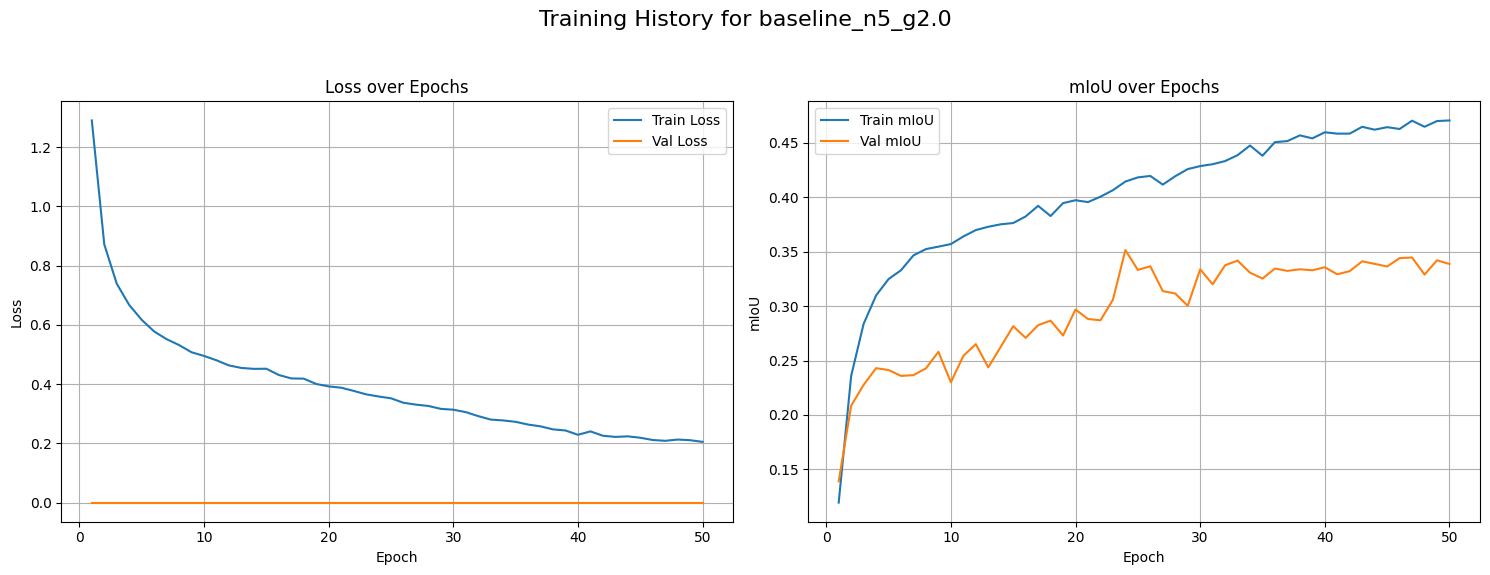

Training curves saved to /content/drive/MyDrive/meriti_project/outputs/baseline_n5_g2.0_training_curves.png

✓ Baseline run complete!
  Best val mIoU: 0.3515
  To run Experiment 1: change CONFIG['n_points_per_class'] and re-run
  To run Experiment 2: change CONFIG['focal_gamma'] and re-run
